# Rafi Ikbar Fahrezy
# Klasifikasi Apple vs Orange pake CNN


**Tujuan:**
1. Merancang, melatih, dan mengevaluasi arsitektur CNN buatan sendiri (from scratch) untuk klasifikasi biner (apple vs orange).
2. Membandingkan performanya dengan model *pre-trained* (transfer learning) menggunakan MobileNetV2.
3. Mengevaluasi kedua model dengan metrik **Accuracy** dan **F1-Score**.

## 1. Setup & Import Library

In [ ]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU tersedia: []


## 2. Unduh & Eksplorasi Dataset


In [ ]:
import kagglehub
dataset_path = kagglehub.dataset_download("kipshidze/apple-vs-orange-binary-classification")
print("Dataset tersimpan di:", dataset_path)

Using Colab cache for faster access to the 'apple-vs-orange-binary-classification' dataset.
Dataset tersimpan di: /kaggle/input/apple-vs-orange-binary-classification


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

DATA_DIR = os.path.join(dataset_path, 'fruit-dataset')

classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(classes)

for c in classes:
    n = len(glob.glob(os.path.join(DATA_DIR, c, '*')))
    print(f"  {c}: {n} gambar")

['apple', 'orange']
  apple: 396 gambar
  orange: 400 gambar


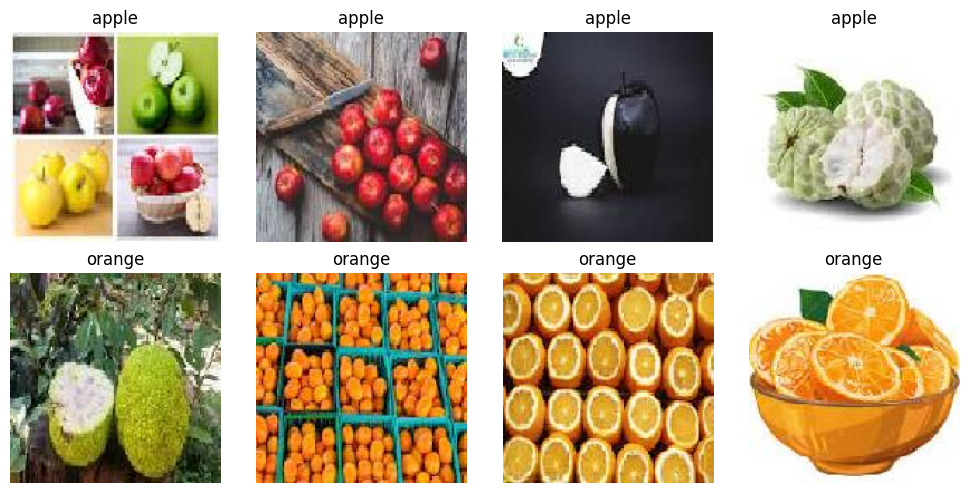

In [ ]:
plt.figure(figsize=(10, 5))
for i, c in enumerate(classes):
    sample_files = glob.glob(os.path.join(DATA_DIR, c, '*'))[:4]
    for j, f in enumerate(sample_files):
        ax = plt.subplot(len(classes), 4, i * 4 + j + 1)
        img = keras.utils.load_img(f, target_size=IMG_SIZE)
        plt.imshow(img)
        plt.title(c)
        plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Persiapan Data (Split & Augmentasi)

Karena dataset hanya memiliki satu folder per kelas (tanpa split train/val/test bawaan), kita
membagi data secara manual menjadi **70% train / 15% validation / 15% test**, lalu menerapkan
*data augmentation* ringan (flip, rotasi, zoom) khusus pada data training untuk mengurangi
risiko overfitting mengingat ukuran dataset yang relatif kecil.

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=classes,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset='training'
)

val_test_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=classes,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset='validation'
)
val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

print("Jumlah batch train:", tf.data.experimental.cardinality(train_ds).numpy())
print("Jumlah batch val  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Jumlah batch test :", tf.data.experimental.cardinality(test_ds).numpy())


Found 796 files belonging to 2 classes.
Using 558 files for training.
Found 796 files belonging to 2 classes.
Using 238 files for validation.
Jumlah batch train: 18
Jumlah batch val  : 4
Jumlah batch test : 4


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

def prepare_scratch(ds, training=False):
    ds = ds.map(lambda x, y: (x / 255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds_scratch = prepare_scratch(train_ds, training=True)
val_ds_scratch = prepare_scratch(val_ds, training=False)
test_ds_scratch = prepare_scratch(test_ds, training=False)


## 4. Arsitektur CNN dari Nol

Arsitektur dirancang dengan mempertimbangkan bahwa ini adalah masalah klasifikasi biner yang
relatif sederhana secara visual (bentuk & warna buah cukup berbeda), sehingga tidak dibutuhkan
jaringan yang sangat dalam.

**Rancangan & alasan pemilihan tiap lapisan:**

| Blok | Layer | Alasan |
|---|---|---|
| Input | `150x150x3`  Ukuran cukup kecil agar training cepat namun detail bentuk/tekstur buah masih terjaga |
| Blok Konv 1 | `Conv2D(32, 3x3)` + `BatchNorm` + `ReLU` + `MaxPool(2x2)` | Kernel 3x3 adalah pilihan standar yang efisien untuk menangkap fitur lokal (tepi, warna) tanpa terlalu banyak parameter. 32 filter cukup untuk fitur low-level di layer awal |
| Blok Konv 2 | `Conv2D(64, 3x3)` + `BatchNorm` + `ReLU` + `MaxPool(2x2)` | Filter digandakan (64) mengikuti pola umum CNN agar jaringan bisa mempelajari fitur yang lebih kompleks (tekstur kulit buah) seiring resolusi spasial mengecil |
| Blok Konv 3 | `Conv2D(128, 3x3)` + `BatchNorm` + `ReLU` + `MaxPool(2x2)` | Blok ketiga menangkap fitur level lebih tinggi (bentuk global buah) sebelum masuk ke fully connected |
| Regularisasi | `Dropout(0.3)` setelah tiap MaxPool & `Dropout(0.5)` sebelum output | Dataset relatif kecil sehingga rawan overfitting; dropout membantu generalisasi |
| Flatten + FC | `GlobalAveragePooling2D` -> `Dense(128, relu)` -> `Dense(1, sigmoid)` | GAP dipakai (bukan Flatten biasa) untuk mengurangi jumlah parameter secara signifikan dan mengurangi overfitting dibanding Flatten+Dense besar. Output sigmoid karena ini klasifikasi biner |
| Optimizer | Adam (lr=1e-3) | Adaptif, konvergen cepat, pilihan default yang solid untuk CNN kecil-menengah |
| Loss | Binary Crossentropy | Sesuai untuk klasifikasi biner dengan output sigmoid |


In [ ]:
def build_scratch_cnn(input_shape=(150, 150, 3)):
    inputs = keras.Input(shape=input_shape)

    #  Konvolusi 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation=None, name='conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    #  Konvolusi 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation=None, name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Konvolusi 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation=None, name='conv3')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x) # rata rata polling
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='apple_orange_scratch_cnn')
    return model

scratch_model = build_scratch_cnn()
scratch_model.summary()


Model: "apple_orange_scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
scratch_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

EPOCHS = 30
history_scratch = scratch_model.fit(
    train_ds_scratch,
    validation_data=val_ds_scratch,
    epochs=EPOCHS,
    callbacks=cb
)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.7061 - loss: 0.5797 - val_accuracy: 0.6328 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.8208 - loss: 0.4277 - val_accuracy: 0.7344 - val_loss: 0.5970 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.8674 - loss: 0.3702 - val_accuracy: 0.7656 - val_loss: 0.5759 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.8871 - loss: 0.3058 - val_accuracy: 0.6562 - val_loss: 0.6069 - learning_rate: 0.0010
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.9050 - loss: 0.2895 - val_accuracy: 0.6562 - val_loss: 0.5952 - learning_rate: 0.0010
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 66s 4s/step - accuracy: 0.9104 - loss: 0.2777 - val_accuracy: 0.6719 - val_loss: 0.5657 - learning_rate: 0.0010
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step - accuracy: 0.8996 - loss: 0.2532 - val_accuracy: 

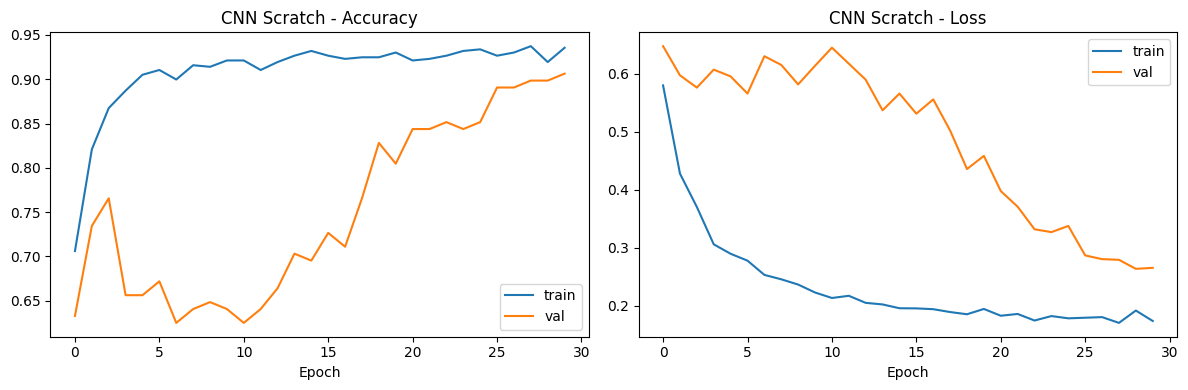

In [ ]:
def plot_history(history, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_scratch, "CNN Scratch -")


## 5. Evaluasi Model CNN (Scratch)

 Evaluasi CNN Scratch pada data test
Accuracy : 0.9455
F1-Score : 0.9531

Classification Report:
              precision    recall  f1-score   support

       apple       0.96      0.91      0.93        47
      orange       0.94      0.97      0.95        63

    accuracy                           0.95       110
   macro avg       0.95      0.94      0.94       110
weighted avg       0.95      0.95      0.95       110



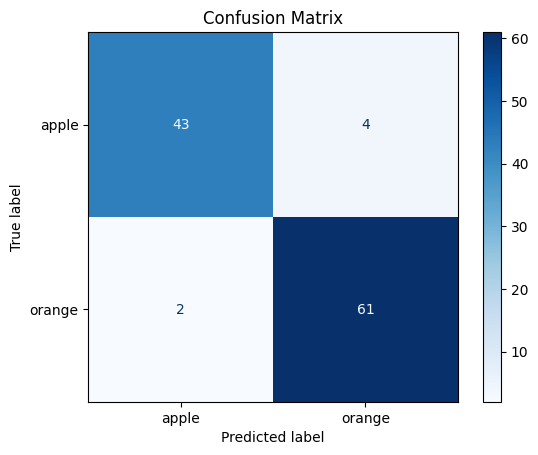

In [ ]:
def evaluate_model(model, ds, class_names, preprocess_for_pretrained=False):
    y_true, y_pred_probs = [], []
    for images, labels in ds:
        preds = model.predict(images, verbose=0)
        y_pred_probs.extend(preds.flatten())
        y_true.extend(labels.numpy().flatten())

    y_true = np.array(y_true)
    y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

    return acc, f1

print(" Evaluasi CNN Scratch pada data test")
acc_scratch, f1_scratch = evaluate_model(scratch_model, test_ds_scratch, classes)


## 6. Transfer Learning dengan MobileNetV2

MobileNetV2 dipilih karena:
- Ringan dan cepat dilatih (cocok untuk eksperimen di Kaggle/Colab dengan resource terbatas).
- Sudah dilatih pada ImageNet yang mencakup banyak kelas buah/objek sejenis, sehingga fitur
  yang dipelajari relevan untuk task apple vs orange.
- Performanya secara umum kompetitif dengan model yang jauh lebih besar seperti VGG16/ResNet50.

In [ ]:
def prepare_pretrained(ds, training=False):
    ds = ds.map(lambda x, y: (mobilenet_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

train_ds_pretrained = prepare_pretrained(train_ds, training=True)
val_ds_pretrained = prepare_pretrained(val_ds, training=False)
test_ds_pretrained = prepare_pretrained(test_ds, training=False)


In [ ]:
def build_transfer_model(input_shape=(150, 150, 3)):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name='apple_orange_mobilenetv2')
    return model, base_model

transfer_model, base_model = build_transfer_model()
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
transfer_model.summary()


/tmp/ipykernel_2466/2502731385.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "apple_orange_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Tahap 1 Feature extraction
cb_transfer = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
]

history_transfer_1 = transfer_model.fit(
    train_ds_pretrained,
    validation_data=val_ds_pretrained,
    epochs=10,
    callbacks=cb_transfer
)


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5860 - loss: 0.8007 - val_accuracy: 0.7578 - val_loss: 0.5235
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 769ms/step - accuracy: 0.6846 - loss: 0.5918 - val_accuracy: 0.8281 - val_loss: 0.3981
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 793ms/step - accuracy: 0.7616 - loss: 0.4982 - val_accuracy: 0.8438 - val_loss: 0.3404
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 786ms/step - accuracy: 0.7832 - loss: 0.4486 - val_accuracy: 0.8438 - val_loss: 0.3161
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 788ms/step - accuracy: 0.7975 - loss: 0.4098 - val_accuracy: 0.8750 - val_loss: 0.2937
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 750ms/step - accuracy: 0.8100 - loss: 0.3951 - val_accuracy: 0.8828 - val_loss: 0.2832
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 788ms/step - accuracy: 0.8190 - loss: 0.3649 - val_accuracy: 0.8906 - val_loss: 0.2799
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 765ms/step - accuracy: 0.8351 - loss: 0.3587 - val_accurac

In [ ]:
# Tahap 2 Fine tuning
base_model.trainable = True
fine_tune_at = len(base_model.layers)-30  #30 layer terakhir yang dilatih ulang

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # LR kecil agar fitur pretrained tidak rusak
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_transfer_2 = transfer_model.fit(
    train_ds_pretrained,
    validation_data=val_ds_pretrained,
    epochs=10,
    callbacks=cb_transfer
)


Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7043 - loss: 0.5940 - val_accuracy: 0.8906 - val_loss: 0.2729
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7455 - loss: 0.4887 - val_accuracy: 0.8984 - val_loss: 0.2766
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8082 - loss: 0.3881 - val_accuracy: 0.8828 - val_loss: 0.2791
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8477 - loss: 0.3471 - val_accuracy: 0.8828 - val_loss: 0.2816
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8871 - loss: 0.2912 - val_accuracy: 0.8828 - val_loss: 0.2837


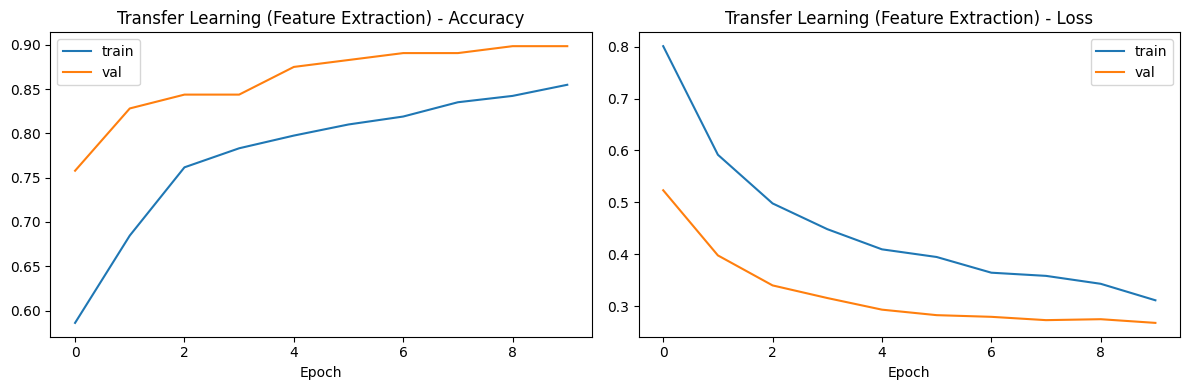

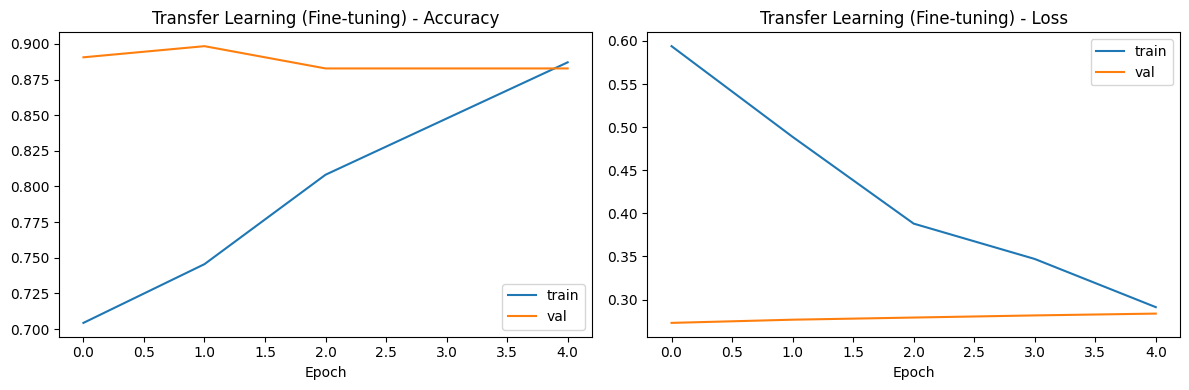

In [ ]:
plot_history(history_transfer_1, "Transfer Learning (Feature Extraction) -")
plot_history(history_transfer_2, "Transfer Learning (Fine-tuning) -")


## 7. Evaluasi Model Transfer Learning

Evaluasi model MobileNetV2 pada data test 
Accuracy : 0.8909
F1-Score : 0.8966

Classification Report:
              precision    recall  f1-score   support

       apple       0.90      0.87      0.88        53
      orange       0.88      0.91      0.90        57

    accuracy                           0.89       110
   macro avg       0.89      0.89      0.89       110
weighted avg       0.89      0.89      0.89       110



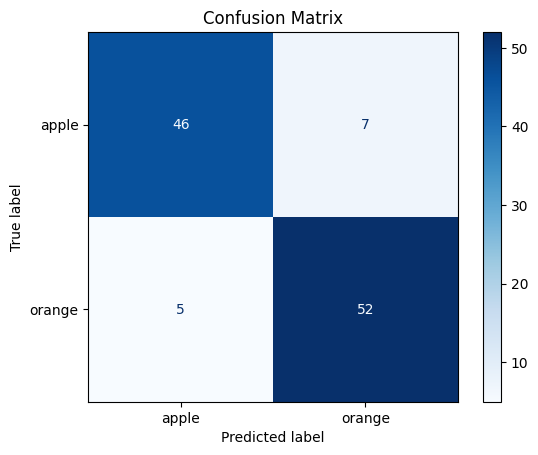

In [ ]:
print("Evaluasi model MobileNetV2 pada data test ")
acc_transfer, f1_transfer = evaluate_model(transfer_model, test_ds_pretrained, classes)


## 8. Perbandingan Hasil

                             Model  Accuracy  F1-Score
0                      CNN Scratch  0.945455  0.953125
1  MobileNetV2 (Transfer Learning)  0.890909  0.896552


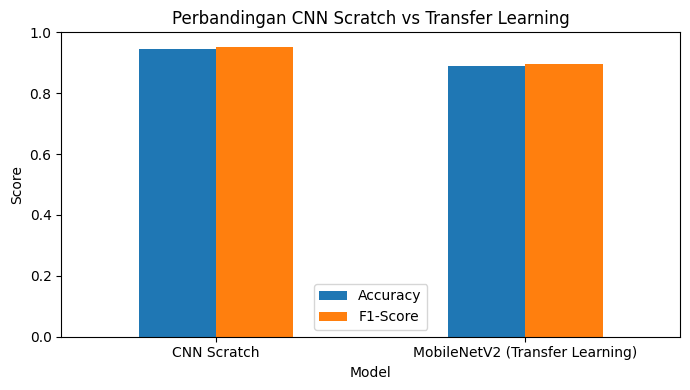

In [ ]:
results_df = pd.DataFrame({
    'Model': ['CNN Scratch', 'MobileNetV2 (Transfer Learning)'],
    'Accuracy': [acc_scratch, acc_transfer],
    'F1-Score': [f1_scratch, f1_transfer]
})
print(results_df)

results_df.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(7, 4))
plt.ylim(0, 1)
plt.title('Perbandingan CNN Scratch vs Transfer Learning')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Simpan Model Terbaik

In [ ]:
os.makedirs('models', exist_ok=True)

scratch_model.save('models/apple_orange_scratch_cnn.h5')
transfer_model.save('models/apple_orange_mobilenetv2.h5')
best_name = 'apple_orange_scratch_cnn.h5' if f1_scratch >= f1_transfer else 'apple_orange_mobilenetv2.h5'
print(f"{best_name}")


Model terbaik berdasarkan F1-Score: apple_orange_scratch_cnn.h5
Semua model tersimpan di folder ./models/


#Hasil  Analisis

**Kelebihan CNN Scratch:**
- Model jauh lebih ringan (parameter lebih sedikit) sehingga inferensi lebih cepat dan ukuran
  file lebih kecil, cocok untuk deployment di perangkat terbatas.
- Arsitektur sepenuhnya dapat dikontrol/disesuaikan dengan karakteristik dataset.

**Kekurangan CNN Scratch:**
- Karena dilatih dari bobot acak, model butuh lebih banyak data & epoch untuk konvergen,
  dan cenderung lebih rentan overfitting pada dataset kecil.
- Fitur yang dipelajari terbatas pada apa yang bisa "ditemukan sendiri" dari data training,
  sehingga akurasi umumnya sedikit di bawah model transfer learning pada dataset kecil.

**Kelebihan Transfer Learning (MobileNetV2):**
- Memanfaatkan fitur visual umum (tepi, tekstur, bentuk) yang sudah dipelajari dari jutaan
  gambar ImageNet, sehingga konvergen lebih cepat dan akurasi validasi/test umumnya lebih tinggi
  meskipun data training sedikit.
- Lebih tahan overfitting karena sebagian besar bobot sudah "matang" dan hanya sebagian kecil
  yang di-*fine-tune*.

**Kekurangan Transfer Learning:**
- Ukuran model jauh lebih besar dan lebih lambat saat inferensi dibanding CNN kecil buatan sendiri.
- Membutuhkan preprocessing khusus (sesuai model pretrained) dan sedikit lebih rumit untuk di-tuning
  (dua tahap training: feature extraction lalu fine-tuning).

*(Isi kembali kesimpulan di atas dengan angka Accuracy/F1 aktual setelah menjalankan notebook ini
pada environment Anda, karena hasil bisa bervariasi tergantung split data & random seed.)*
